# Experiment 3 — Full Fine-Tuning with Imbalance Handling for CDT Classification

**Project:** Deep Learning-Based Approach for Cognitive Decline Screening Through Clock Drawing Test Image Analysis  
**Experiment:** Experiment 3 — Full Fine-Tuning with Imbalance Handling  
**Model Setup:** ImageNet-pretrained ResNet18 backbone with 100% trainable layers  
**Supplementary Strategies:** Class weighting and oversampling  
**Output Classes:** `Impaired`, `Mild`, `Normal`

<br>

---

<br>

## Experiment Purpose

Experiment 3 applies full fine-tuning by making the entire ResNet18 backbone trainable. This allows the model to adapt all pretrained feature layers to the Clock Drawing Test dataset.

To address class imbalance, this experiment also uses oversampling and class weighting to improve learning for the minority classes, particularly `Impaired` and `Mild`.

<br>

---

<br>

## Main Difference from Experiments 1 and 2

| Experiment | Backbone Setup | Imbalance Handling | Purpose |
|---|---|---|---|
| Experiment 1 | Fully frozen backbone | Standard augmentation | Baseline feature extraction |
| Experiment 2 | Last 30% unfrozen | Standard augmentation | Partial adaptation |
| Experiment 3 | 100% trainable backbone | Oversampling + class weights | Full adaptation with minority-class support |

<br>

> **Research note:** Experiment 3 evaluates full backbone fine-tuning while also testing whether imbalance-handling strategies improve detection of `Impaired` and `Mild` cases.

---
# Section 1 — Environment Setup and Library Imports

The required libraries are prepared for model loading, dataset processing, imbalance handling, training, visualization, and evaluation.

In [ ]:
# ============================================================
# SECTION 1: ENVIRONMENT SETUP AND LIBRARY IMPORTS
# ============================================================

!pip install -q keras-hub keras

import os
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import keras
import keras_hub
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support
)

print("Keras version      :", keras.__version__)
print("TensorFlow version :", tf.__version__)

Environment ready.
Keras version      : 3.13.2
TensorFlow version : 2.20.0


---
# Section 2 — Load the ImageNet-Pretrained ResNet18 Backbone

An ImageNet-pretrained ResNet18 backbone is initialized through KerasHub. This backbone provides the pretrained visual feature extractor that will later be fully fine-tuned for CDT classification.

<br>

> **Research note:** Full fine-tuning allows the pretrained feature layers to adapt directly to the Clock Drawing Test dataset.

In [ ]:
# ============================================================
# SECTION 2: LOAD PRETRAINED RESNET18 BACKBONE
# ============================================================

backbone = keras_hub.models.ResNetBackbone.from_preset("resnet_18_imagenet")

print("ResNet18 backbone loaded successfully.")
print("Expected input shape : (None, 224, 224, 3)")
print("Total backbone layers:", len(backbone.layers))

ResNet18 backbone loaded successfully.
Expected input shape : (None, 224, 224, 3)
Total backbone layers: 72


## Section 2.1 — Inspect the Backbone Before Full Fine-Tuning

The backbone architecture is reviewed before applying the full fine-tuning setup. Trainable-layer verification is performed later after all backbone layers are explicitly set to trainable.

In [ ]:
# ============================================================
# SECTION 2.1: BACKBONE INSPECTION BEFORE FULL FINE-TUNING
# ============================================================

backbone.summary()

print("\nLast 10 backbone layers:")
for layer in backbone.layers[-10:]:
    print(f"{layer.name:<45} | {layer.__class__.__name__:<25} | trainable: {layer.trainable}")

Model: "res_net_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, None,      │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,408 │ conv1_pad[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, None,      │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_co… │ (None, None,      │     36,864 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_bn  │ (None, None,      │        256 │ stack0_block0_1_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_re… │ (None, None,      │          0 │ stack0_block0_1_… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_2_co… │ (None, None,      │     36,864 │ stack0_block0_1_… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_2_bn  │ (None, None,      │        256 │ stack0_block0_2_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_add   │ (None, None,      │          0 │ pool1_pool[0][0], │
│ (Add)               │ None, 64)         │            │ stack0_block0_2_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_out   │ (None, None,      │          0 │ stack0_block0_ad… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block1_1_co… │ (None, None,      │     36,864 │ stack0_block0_ou… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block1_1_bn  │ (None, None,      │        256 │ stack0_block1_1_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block1_1_re… │ (None, None,      │          0 │ stack0_block1_1_

 Total params: 11,186,112 (42.67 MB)

 Trainable params: 11,176,512 (42.64 MB)

 Non-trainable params: 9,600 (37.50 KB)


Last 10 backbone layers:
stack3_block0_2_bn                            | BatchNormalization        | trainable: True
stack3_block0_add                             | Add                       | trainable: True
stack3_block0_out                             | Activation                | trainable: True
stack3_block1_1_conv                          | Conv2D                    | trainable: True
stack3_block1_1_bn                            | BatchNormalization        | trainable: True
stack3_block1_1_relu                          | Activation                | trainable: True
stack3_block1_2_conv                          | Conv2D                    | trainable: True
stack3_block1_2_bn                            | BatchNormalization        | trainable: True
stack3_block1_add                             | Add                       | trainable: True
stack3_block1_out                             | Activation                | trainable: True


---
# Section 3 — Mount Google Drive and Load the CDT Dataset


In [ ]:
# ============================================================
# SECTION 3: MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# SECTION 3.1: DATASET AND OUTPUT CONFIGURATION
# ============================================================

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = (224, 224, 3)
SEED = 123

FOLDER_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset/Experiment_data_3class"

SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/models"

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "exp3_fullfinetune_imbalance_best.keras")
FINAL_MODEL_PATH = os.path.join(SAVE_DIR, "exp3_fullfinetune_imbalance_final.keras")
SUMMARY_CSV_PATH = os.path.join(SAVE_DIR, "exp3_summary_metrics.csv")
PER_CLASS_CSV_PATH = os.path.join(SAVE_DIR, "exp3_per_class_metrics.csv")

print("Dataset path     :", FOLDER_PATH)
print("Best model path  :", BEST_MODEL_PATH)
print("Final model path :", FINAL_MODEL_PATH)

Configuration loaded.
Dataset path     : /content/drive/MyDrive/Colab Notebooks/dataset/Experiment_data_3class
Best model path  : /content/drive/MyDrive/Colab Notebooks/models/exp3_fullfinetune_imbalance_best.keras
Final model path : /content/drive/MyDrive/Colab Notebooks/models/exp3_fullfinetune_imbalance_final.keras


In [ ]:
# ============================================================
# SECTION 3.2: LOAD TRAINING AND VALIDATION DATASETS
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory=FOLDER_PATH,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    subset="training",
    interpolation="area",
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    directory=FOLDER_PATH,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    subset="validation",
    interpolation="area",
    seed=SEED
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("\nDataset loaded.")
print("Class names       :", class_names)
print("Number of classes :", num_classes)

Found 1638 files belonging to 3 classes.
Using 1311 files for training.
Found 1638 files belonging to 3 classes.
Using 327 files for validation.

Dataset loaded.
Class names       : ['Impaired', 'Mild', 'Normal']
Number of classes : 3



## Section 3.3 — Check Class Distribution

In [ ]:
# ============================================================
# SECTION 3.3: CLASS DISTRIBUTION CHECK
# ============================================================

def count_dataset_classes(dataset, class_names):

    counter = Counter()

    for _, labels in dataset.unbatch():
        counter[int(labels.numpy())] += 1

    for class_index, count in sorted(counter.items()):
        print(f"{class_names[class_index]:<12}: {count} samples")

    return counter


print("Training Set Distribution")
print("-" * 35)
train_counts = count_dataset_classes(train_ds, class_names)

print("\nValidation Set Distribution")
print("-" * 35)
val_counts = count_dataset_classes(val_ds, class_names)

Training Set Distribution
-----------------------------------
Impaired    : 70 samples
Mild        : 288 samples
Normal      : 953 samples

Validation Set Distribution
-----------------------------------
Impaired    : 16 samples
Mild        : 64 samples
Normal      : 247 samples


---
# Section 4 — Normalize the Images

Pixel values are scaled from `[0, 255]` to `[0.0, 1.0]` to support more stable and efficient model training.

In [ ]:
# ============================================================
# SECTION 4: IMAGE NORMALIZATION
# ============================================================

def normalize_image(image, label):
    """Convert image pixels from [0, 255] to [0.0, 1.0]."""
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


train_ds = train_ds.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)

Normalization complete. Pixel values are now scaled to [0.0, 1.0].


---
# Section 5 — Data Augmentation

Online augmentation is applied only to the training set to improve robustness against small variations in CDT images.

> **Implementation note:** Augmentation is applied dynamically during training and does not create additional saved image files.

In [ ]:
# ============================================================
# SECTION 5: ONLINE DATA AUGMENTATION
# ============================================================

# These augmentation layers follow the current Experiment 3 setup.
# They are applied dynamically to the training set only.
data_augmentation_layers = [
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
]

def data_augmentation(images, labels):
    for layer in data_augmentation_layers:
        images = layer(images, training=True)
    return images, labels


augmented_train_dataset = train_ds.map(
    data_augmentation,
    num_parallel_calls=tf.data.AUTOTUNE
)

augmented_train_dataset = augmented_train_dataset.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

Online augmentation configured for the training set only.
Augmentations: Rotation | Zoom | Translation


## Section 5.1 — Augmentation Exposure Estimate

Dynamic augmentation keeps the number of saved image files unchanged. Instead, the model is exposed to transformed training views across epochs.

```text
Approximate exposure = training images per epoch × completed epochs

In [ ]:
# ============================================================
# SECTION 5.1: AUGMENTATION EXPOSURE NOTE
# ============================================================

train_total = sum(train_counts.values())

print("Original training images per epoch:", train_total)
print("Augmentation type                 : Online / dynamic augmentation")
print("Saved augmented files             : 0")
print("Exposure formula                  : training images × completed epochs")

Original training images per epoch: 1311
Augmentation type                 : Online / dynamic augmentation
Saved augmented files             : 0
Exposure formula                  : training images × completed epochs



---
# Section 6 — Compute Class Weights

Class weights are calculated to reduce the effect of class imbalance. Minority classes receive higher weights so that misclassifying them contributes more strongly to the training loss.

<br>

> **Implementation note:** Class weights do not create new images. They adjust the loss contribution of each class during training.

In [ ]:
# ============================================================
# SECTION 6: COMPUTE CLASS WEIGHTS
# ============================================================

# Class weights penalize the model more for misclassifying rare classes.
# Formula: weight = total_samples / (num_classes * class_count)

total_train = sum(train_counts.values())
num_classes_cw = len(class_names)

class_weights = {
    class_idx: total_train / (num_classes_cw * count)
    for class_idx, count in train_counts.items()
}

print("Class weights:")
for idx, weight in sorted(class_weights.items()):
    print(f"  {class_names[idx]} (class {idx}): {weight:.4f}")

Class weights:
  Impaired (class 0): 6.2429
  Mild (class 1): 1.5174
  Normal (class 2): 0.4586


---
# Section 7 — Oversample Minority Classes

Minority classes are oversampled in the training set so that each class receives equal representation during training.

Key controls:

- Oversampling is applied only to the training set.
- The validation set remains unchanged.
- This prevents artificially inflated validation results.

<br>

> **Implementation note:** Oversampling increases minority-class exposure, while class weights increase the penalty for minority-class errors.

In [ ]:
# ============================================================
# SECTION 7: OVERSAMPLE MINORITY CLASSES
# ============================================================

# Step 1 — Collect all training images and labels into NumPy arrays.
# This makes oversampling faster and easier to control.
all_images = []
all_labels = []

for images, labels in train_ds.unbatch():
    all_images.append(images.numpy())
    all_labels.append(labels.numpy())

all_images = np.array(all_images)
all_labels = np.array(all_labels)

print(f"Collected {len(all_images)} training images into memory.")

# Step 2 — Oversample each class to match the largest training class.
target_count = max(train_counts.values())

print(f"\nTarget count per class: {target_count}")

balanced_images = []
balanced_labels = []

for class_idx in range(num_classes):
    class_mask = all_labels == class_idx
    class_images = all_images[class_mask]
    class_labels = all_labels[class_mask]
    current_count = len(class_images)

    # Randomly sample with replacement until the class reaches the target count.
    indices = np.random.choice(current_count, size=target_count, replace=True)

    balanced_images.append(class_images[indices])
    balanced_labels.append(class_labels[indices])

    print(f"  {class_names[class_idx]}: {current_count} → {target_count}")

balanced_images = np.concatenate(balanced_images, axis=0)
balanced_labels = np.concatenate(balanced_labels, axis=0)

# Step 3 — Shuffle the balanced training set.
shuffle_idx = np.random.permutation(len(balanced_images))
balanced_images = balanced_images[shuffle_idx]
balanced_labels = balanced_labels[shuffle_idx]

print(f"\nTotal balanced training samples: {len(balanced_images)}")

# Step 4 — Build a TensorFlow dataset from the balanced arrays.
balanced_train_ds = tf.data.Dataset.from_tensor_slices(
    (balanced_images, balanced_labels)
)

balanced_train_ds = (
    balanced_train_ds
    .shuffle(buffer_size=1000, seed=42)
    .batch(BATCH_SIZE)
    .map(data_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

print("\nBalanced training dataset created successfully.")
print("Oversampling was applied only to the training set.")

Collected 1311 training images into memory.

Target count per class: 953
  Impaired: 70 → 953
  Mild: 288 → 953
  Normal: 953 → 953

Total balanced training samples: 2859

Balanced training dataset created successfully.
Oversampling was applied only to the training set.


## Section 7.1 — Verify Balanced Training Set

The post-oversampling distribution is checked to confirm that all training classes have equal sample counts.

In [ ]:
# ============================================================
# SECTION 7.1: VERIFY BALANCED TRAINING DISTRIBUTION
# ============================================================

balanced_counts = Counter(balanced_labels)

print("Balanced Training Set Distribution")
print("-" * 40)

for class_index, count in sorted(balanced_counts.items()):
    print(f"{class_names[class_index]:<12}: {count} samples")

Balanced Training Set Distribution
----------------------------------------
Impaired    : 953 samples
Mild        : 953 samples
Normal      : 953 samples


---
# Section 8 — Apply Full Fine-Tuning to the ResNet18 Backbone

All ResNet18 backbone layers are made trainable for Experiment 3. This allows the model to adapt both low-level and high-level pretrained features to CDT image patterns.

<br>

> **Research note:** Full fine-tuning increases model flexibility but also raises overfitting risk, especially with limited and imbalanced data. Oversampling and class weighting are included to support minority-class learning.

In [ ]:
# ============================================================
# SECTION 8: APPLY FULL FINE-TUNING
# ============================================================

# In Experiment 3, all backbone layers are trainable.
# This allows the full pretrained ResNet18 feature extractor to adapt to CDT images.
for layer in backbone.layers:
    layer.trainable = True

total_backbone_layers = len(backbone.layers)
backbone_trainable_layers = sum(1 for layer in backbone.layers if layer.trainable)
backbone_frozen_layers = sum(1 for layer in backbone.layers if not layer.trainable)

print("Full fine-tuning configuration applied.")
print("Total backbone layers             :", total_backbone_layers)
print("Backbone trainable internal layers:", backbone_trainable_layers)
print("Backbone frozen internal layers   :", backbone_frozen_layers)

Full fine-tuning configuration applied.
Total backbone layers             : 72
Backbone trainable internal layers: 72
Backbone frozen internal layers   : 0


---
# Section 9 — Build the Experiment 3 Model

The fully trainable ResNet18 backbone is connected to a custom classifier head for CDT classification.

Model flow:

```text
Input Image
↓
Fully Trainable ResNet18 Backbone
↓
Global Average Pooling
↓
Dense Layer
↓
Dropout
↓
Softmax Classifier

In [ ]:

# ============================================================
# SECTION 9: BUILD EXPERIMENT 3 MODEL
# ============================================================

inputs = keras.Input(shape=INPUT_SHAPE, name="input_image")

x = backbone(inputs)

x = keras.layers.GlobalAveragePooling2D(name="global_average_pooling2d")(x)

x = keras.layers.Dense(256, activation="relu", name="cdt_dense_256")(x)
x = keras.layers.Dropout(0.50, name="cdt_dropout")(x)

outputs = keras.layers.Dense(
    num_classes,
    activation="softmax",
    name="cdt_classifier"
)(x)

exp3_model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="Experiment3_FullFineTune_ResNet18_ImbalanceHandling"
)

print("Experiment 3 model built successfully.")

Experiment 3 model built successfully.


## Section 9.1 — Model Summary


In [ ]:
# ============================================================
# SECTION 9.1: MODEL SUMMARY
# ============================================================

exp3_model.summary()

print("\nModel name        :", exp3_model.name)
print("Input shape       :", exp3_model.input_shape)
print("Output shape      :", exp3_model.output_shape)
print("Number of classes :", num_classes)
print("Class names       :", class_names)

Model: "Experiment3_FullFineTune_ResNet18_ImbalanceHandling"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_net_backbone                │ (None, 7, 7, 512)      │    11,186,112 │
│ (ResNetBackbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cdt_dense_256 (Dense)           │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cdt_dropout (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cdt_classifier (Dense)          │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,318,211 (43.18 MB)

 Trainable params: 11,308,611 (43.14 MB)

 Non-trainable params: 9,600 (37.50 KB)


Model name        : Experiment3_FullFineTune_ResNet18_ImbalanceHandling
Input shape       : (None, 224, 224, 3)
Output shape      : (None, 3)
Number of classes : 3
Class names       : ['Impaired', 'Mild', 'Normal']


---
# Section 10 — Verify Full Fine-Tuning Setup

The trainable-layer configuration is verified to confirm that all internal ResNet18 backbone layers and the custom classifier head are trainable.
<br>

> **Implementation note:** This verification ensures that Experiment 3 reflects the intended full fine-tuning setup.

In [ ]:
# ============================================================
# SECTION 10: VERIFY FULL FINE-TUNING SETUP
# ============================================================

# Top-level model layer verification
trainable_top_layers = [layer.name for layer in exp3_model.layers if layer.trainable]
frozen_top_layers = [layer.name for layer in exp3_model.layers if not layer.trainable]

print("Top-Level Model Layer Verification")
print("-" * 50)
print("Trainable top-level layers:", len(trainable_top_layers))
print(trainable_top_layers)

print("\nFrozen top-level layers:", len(frozen_top_layers))
print(frozen_top_layers)

# Internal backbone verification
backbone_trainable_layers = [layer.name for layer in backbone.layers if layer.trainable]
backbone_frozen_layers = [layer.name for layer in backbone.layers if not layer.trainable]

print("\nInternal Backbone Verification")
print("-" * 50)
print("Backbone trainable internal layers:", len(backbone_trainable_layers))
print("Backbone frozen internal layers   :", len(backbone_frozen_layers))

print("\nFirst 10 trainable backbone layers:")
print(backbone_trainable_layers[:10])

print("\nLast 10 trainable backbone layers:")
print(backbone_trainable_layers[-10:])

# Weight tensor verification
print("\nWeight Tensor Verification")
print("-" * 50)
print("Trainable weight tensors    :", len(exp3_model.trainable_weights))
print("Non-trainable weight tensors:", len(exp3_model.non_trainable_weights))

Top-Level Model Layer Verification
--------------------------------------------------
Trainable top-level layers: 6
['input_image', 'res_net_backbone', 'global_average_pooling2d', 'cdt_dense_256', 'cdt_dropout', 'cdt_classifier']

Frozen top-level layers: 0
[]

Internal Backbone Verification
--------------------------------------------------
Backbone trainable internal layers: 72
Backbone frozen internal layers   : 0

First 10 trainable backbone layers:
['input_layer_3', 'conv1_pad', 'conv1_conv', 'conv1_bn', 'conv1_relu', 'pool1_pad', 'pool1_pool', 'stack0_block0_1_conv', 'stack0_block0_1_bn', 'stack0_block0_1_relu']

Last 10 trainable backbone layers:
['stack3_block0_2_bn', 'stack3_block0_add', 'stack3_block0_out', 'stack3_block1_1_conv', 'stack3_block1_1_bn', 'stack3_block1_1_relu', 'stack3_block1_2_conv', 'stack3_block1_2_bn', 'stack3_block1_add', 'stack3_block1_out']

Weight Tensor Verification
--------------------------------------------------
Trainable weight tensors    : 64
Non

---
# Section 11 — Compile the Experiment 3 Model

The model is compiled using Adam optimization, sparse categorical cross-entropy, and accuracy monitoring.

Configuration:

- **Optimizer:** Adam
- **Learning rate:** 1e-3
- **Loss function:** Sparse categorical cross-entropy
- **Metric:** Accuracy

<br>

> **Research note:** Accuracy is monitored during training, but final interpretation also relies on macro F1-score and per-class recall because the dataset is imbalanced.

In [ ]:
# ============================================================
# SECTION 11: COMPILE EXPERIMENT 3 MODEL
# ============================================================

exp3_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Experiment 3 model compiled successfully.")
print("Optimizer      : Adam")
print("Learning rate  : 1e-3")
print("Loss function  : Sparse categorical cross-entropy")
print("Training metric: Accuracy")

Experiment 3 model compiled successfully.
Optimizer      : Adam
Learning rate  : 1e-3
Loss function  : Sparse categorical cross-entropy
Training metric: Accuracy


---
# Section 12 — Training Callbacks

Training is controlled using early stopping and model checkpointing.

- **EarlyStopping** prevents unnecessary training once validation loss stops improving.
- **ModelCheckpoint** saves the best-performing model based on validation loss.

<br>

> **Implementation note:** Early stopping is especially important in full fine-tuning because all backbone layers are being updated.

In [ ]:
# ============================================================
# SECTION 12: TRAINING CALLBACKS
# ============================================================

# Create the model-saving folder only after Google Drive has been mounted.
os.makedirs(SAVE_DIR, exist_ok=True)

early_stopping_callback = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

callbacks_list = [
    early_stopping_callback,
    checkpoint_callback
]

print("EarlyStopping monitor :", "val_loss")
print("EarlyStopping patience:", 5)
print("Checkpoint path       :", BEST_MODEL_PATH)

Callbacks configured.
EarlyStopping monitor : val_loss
EarlyStopping patience: 5
Checkpoint path       : /content/drive/MyDrive/Colab Notebooks/models/exp3_fullfinetune_imbalance_best.keras


---
# Section 13 — Train the Experiment 3 Model

The model is trained using the balanced and augmented training dataset.

Training setup:

- The training set is balanced through oversampling.
- Online augmentation is applied to the balanced training set.
- Class weights are passed during training.
- The validation set remains unchanged.

<br>

> **Implementation note:** Oversampling and class weights affect only training. Validation remains untouched for fair evaluation.

In [ ]:
# ============================================================
# SECTION 13: TRAIN EXPERIMENT 3 MODEL
# ============================================================

training_history = exp3_model.fit(
    balanced_train_ds,
    epochs=20,
    validation_data=val_ds,
    class_weight=class_weights,
    callbacks=callbacks_list
)

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.4817 - loss: 1.4130
Epoch 1: val_loss improved from None to 1.28158, saving model to /content/drive/MyDrive/Colab Notebooks/models/exp3_fullfinetune_imbalance_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/models/exp3_fullfinetune_imbalance_best.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 70s 523ms/step - accuracy: 0.6306 - loss: 0.9244 - val_accuracy: 0.2783 - val_loss: 1.2816
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.8692 - loss: 0.3680
Epoch 2: val_loss did not improve from 1.28158
90/90 ━━━━━━━━━━━━━━━━━━━━ 36s 397ms/step - accuracy: 0.8678 - loss: 0.3645 - val_accuracy: 0.4251 - val_loss: 1.4403
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.9195 - loss: 0.2086
Epoch 3: val_loss improved from 1.28158 to 0.72998, saving model to /content/drive/MyDrive/Colab Notebooks/models/exp3_fullfinetune_imbalance_best.keras

Epoch 3: finished saving model to /

## Section 13.1 — Training Summary

The completed training run is summarized using completed epochs, best validation loss, best validation accuracy, original training count, balanced training count, and estimated augmented training exposure.

In [ ]:
# ============================================================
# SECTION 13.1: TRAINING SUMMARY
# ============================================================

history_dict = training_history.history

completed_epochs = len(history_dict["loss"])

best_val_loss = min(history_dict["val_loss"])
best_val_loss_epoch = history_dict["val_loss"].index(best_val_loss) + 1

best_val_accuracy = max(history_dict["val_accuracy"])
best_val_accuracy_epoch = history_dict["val_accuracy"].index(best_val_accuracy) + 1

original_training_samples = train_total
balanced_training_samples = len(balanced_images)

approx_augmented_exposures = balanced_training_samples * completed_epochs

print("Experiment 3 Training Summary")
print("-" * 55)
print(f"Completed epochs                       : {completed_epochs}")
print(f"Best validation loss                   : {best_val_loss:.4f} at epoch {best_val_loss_epoch}")
print(f"Best validation accuracy               : {best_val_accuracy:.4f} at epoch {best_val_accuracy_epoch}")
print(f"Original training images per epoch     : {original_training_samples}")
print(f"Balanced training images per epoch     : {balanced_training_samples}")
print(f"Approx. augmented training views       : {approx_augmented_exposures}")
print(f"Best model saved to                    : {BEST_MODEL_PATH}")

Experiment 3 Training Summary
-------------------------------------------------------
Completed epochs                       : 9
Best validation loss                   : 0.3803 at epoch 4
Best validation accuracy               : 0.8807 at epoch 4
Original training images per epoch     : 1311
Balanced training images per epoch     : 2859
Approx. augmented training views       : 25731
Best model saved to                    : /content/drive/MyDrive/Colab Notebooks/models/exp3_fullfinetune_imbalance_best.keras


## Section 13.2 — Initial Training Interpretation

Training results are interpreted cautiously because Experiment 3 is designed to improve minority-class recognition, not only overall accuracy.

Final conclusions are based on per-class precision, recall, F1-score, macro F1-score, weighted metrics, and confusion matrix analysis.

---
# Section 14 — Training Curves

Training and validation curves are plotted to examine the learning behavior of the full fine-tuning model.

The curves help identify whether the model improved, plateaued, or showed signs of overfitting.

In [ ]:
# ============================================================
# SECTION 14: PREPARE TRAINING HISTORY VALUES
# ============================================================

history_dict = training_history.history

loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]

accuracy_values = history_dict["accuracy"]
val_accuracy_values = history_dict["val_accuracy"]

epochs_range = range(1, len(loss_values) + 1)

best_val_loss = min(val_loss_values)
best_val_loss_epoch = val_loss_values.index(best_val_loss) + 1

best_val_accuracy = max(val_accuracy_values)
best_val_accuracy_epoch = val_accuracy_values.index(best_val_accuracy) + 1

print("Training history prepared.")
print(f"Completed epochs         : {len(loss_values)}")
print(f"Best validation loss     : {best_val_loss:.4f} at epoch {best_val_loss_epoch}")
print(f"Best validation accuracy : {best_val_accuracy:.4f} at epoch {best_val_accuracy_epoch}")

Training history prepared.
Completed epochs         : 9
Best validation loss     : 0.3803 at epoch 4
Best validation accuracy : 0.8807 at epoch 4


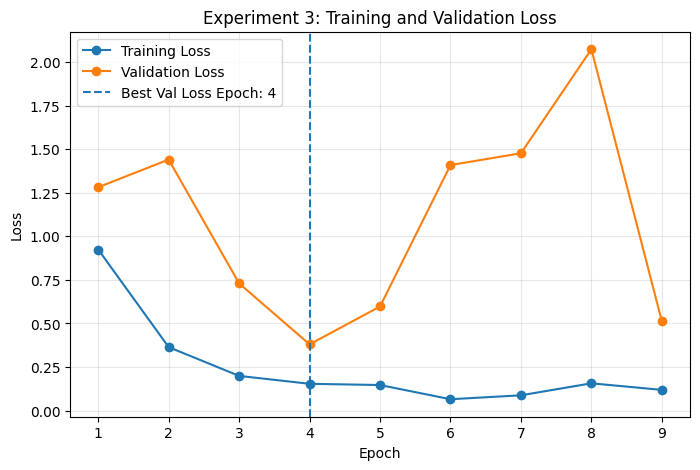

In [ ]:
# ============================================================
# SECTION 14.1: TRAINING AND VALIDATION LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    loss_values,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_loss_values,
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    best_val_loss_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch: {best_val_loss_epoch}"
)

plt.title("Experiment 3: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs_range))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

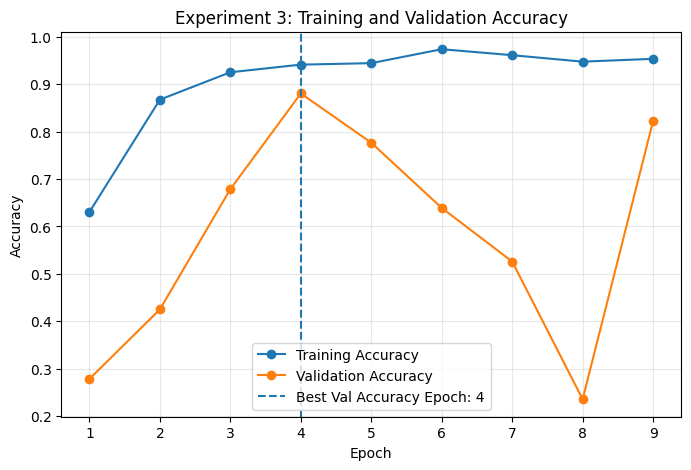

In [ ]:
# ============================================================
# SECTION 14.2: TRAINING AND VALIDATION ACCURACY CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    accuracy_values,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_accuracy_values,
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    best_val_accuracy_epoch,
    linestyle="--",
    label=f"Best Val Accuracy Epoch: {best_val_accuracy_epoch}"
)

plt.title("Experiment 3: Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(epochs_range))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
# Section 15 — Evaluate the Experiment 3 Model

The trained model is evaluated on the unchanged validation set using overall and class-level metrics.

Evaluation includes:

- Accuracy
- Per-class precision
- Per-class recall
- Per-class F1-score
- Macro average
- Micro average
- Weighted average
- Confusion matrix

<br>

> **Research note:** Experiment 3 may not produce the highest accuracy, but it may provide stronger screening-sensitive performance through better recall for `Impaired` and `Mild`.

In [ ]:
# ============================================================
# SECTION 15: BASIC VALIDATION EVALUATION
# ============================================================

val_loss, val_accuracy = exp3_model.evaluate(val_ds, verbose=1)

print("Experiment 3 Validation Results")
print("-" * 55)
print(f"Validation Loss    : {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.8807 - loss: 0.3803
Experiment 3 Validation Results
-------------------------------------------------------
Validation Loss    : 0.3803
Validation Accuracy: 0.8807


In [ ]:
# ============================================================
# SECTION 15.1: EXTRACT TRUE LABELS AND MODEL PREDICTIONS
# ============================================================

y_true = []
y_pred = []
y_pred_probabilities = []

for images, labels in val_ds:
    # The model outputs softmax probabilities for each class.
    predictions = exp3_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)
    y_pred_probabilities.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_probabilities = np.array(y_pred_probabilities)

print("Number of validation samples :", len(y_true))
print("Number of predictions        :", len(y_pred))
print("Prediction probability shape :", y_pred_probabilities.shape)

Prediction extraction complete.
Number of validation samples : 327
Number of predictions        : 327
Prediction probability shape : (327, 3)


## Section 15.2 — Classification Report

The classification report provides class-level precision, recall, F1-score, and support. This is essential for evaluating whether the model performs well across all CDT categories.

In [ ]:
# ============================================================
# SECTION 15.2: CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("Experiment 3 Classification Report")
print("-" * 55)
print(report)

Experiment 3 Classification Report
-------------------------------------------------------
              precision    recall  f1-score   support

    Impaired     0.5200    0.8125    0.6341        16
        Mild     0.7679    0.6719    0.7167        64
      Normal     0.9431    0.9393    0.9412       247

    accuracy                         0.8807       327
   macro avg     0.7436    0.8079    0.7640       327
weighted avg     0.8881    0.8807    0.8822       327



In [ ]:
# ============================================================
# SECTION 15.3: MACRO, MICRO, AND WEIGHTED METRICS
# ============================================================

accuracy = accuracy_score(y_true, y_pred)

macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

micro_precision = precision_score(y_true, y_pred, average="micro", zero_division=0)
micro_recall = recall_score(y_true, y_pred, average="micro", zero_division=0)
micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)

weighted_precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
weighted_recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("Experiment 3 Summary Metrics")
print("-" * 55)
print(f"Accuracy           : {accuracy:.4f}")
print(f"Macro Precision    : {macro_precision:.4f}")
print(f"Macro Recall       : {macro_recall:.4f}")
print(f"Macro F1-score     : {macro_f1:.4f}")
print(f"Micro Precision    : {micro_precision:.4f}")
print(f"Micro Recall       : {micro_recall:.4f}")
print(f"Micro F1-score     : {micro_f1:.4f}")
print(f"Weighted Precision : {weighted_precision:.4f}")
print(f"Weighted Recall    : {weighted_recall:.4f}")
print(f"Weighted F1-score  : {weighted_f1:.4f}")

Experiment 3 Summary Metrics
-------------------------------------------------------
Accuracy           : 0.8807
Macro Precision    : 0.7436
Macro Recall       : 0.8079
Macro F1-score     : 0.7640
Micro Precision    : 0.8807
Micro Recall       : 0.8807
Micro F1-score     : 0.8807
Weighted Precision : 0.8881
Weighted Recall    : 0.8807
Weighted F1-score  : 0.8822


---
# Section 16 — Confusion Matrix

For Experiment 3, it is used to examine whether oversampling and class weighting improved recognition of `Impaired` and `Mild` instead of favoring only `Normal`.

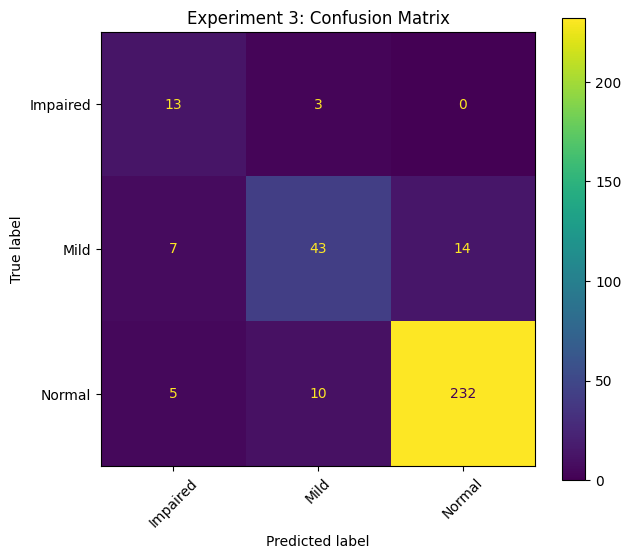

In [ ]:
# ============================================================
# SECTION 16: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=45
)

plt.title("Experiment 3: Confusion Matrix")
plt.show()

In [ ]:
# ============================================================
# SECTION 16.1: CONFUSION MATRIX TABLE
# ============================================================

confusion_matrix_df = pd.DataFrame(
    cm,
    index=[f"Actual {name}" for name in class_names],
    columns=[f"Predicted {name}" for name in class_names]
)

confusion_matrix_df

,Predicted Impaired,Predicted Mild,Predicted Normal
Actual Impaired,13,3,0
Actual Mild,7,43,14
Actual Normal,5,10,232


---
# Section 17 — Result Tables

Clean result tables are prepared for documentation and comparison.

The first table presents per-class performance.  
The second table summarizes the overall Experiment 3 results.

In [ ]:
# ============================================================
# SECTION 17: PER-CLASS METRICS TABLE
# ============================================================

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=range(len(class_names)),
    zero_division=0
)

per_class_metrics_df = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Support": support
})

per_class_metrics_df

,Class,Precision,Recall,F1-score,Support
0,Impaired,0.520000,0.812500,0.634146,16
1,Mild,0.767857,0.671875,0.716667,64
2,Normal,0.943089,0.939271,0.941176,247


In [ ]:
# ============================================================
# SECTION 17.1: EXPERIMENT 3 SUMMARY TABLE
# ============================================================

exp3_summary_df = pd.DataFrame({
    "Experiment": ["Experiment 3 - Full Fine-Tuning with Imbalance Handling"],
    "Validation Loss": [val_loss],
    "Validation Accuracy": [accuracy],
    "Macro Precision": [macro_precision],
    "Macro Recall": [macro_recall],
    "Macro F1-score": [macro_f1],
    "Micro Precision": [micro_precision],
    "Micro Recall": [micro_recall],
    "Micro F1-score": [micro_f1],
    "Weighted Precision": [weighted_precision],
    "Weighted Recall": [weighted_recall],
    "Weighted F1-score": [weighted_f1],
    "Completed Epochs": [completed_epochs],
    "Best Val Loss": [best_val_loss],
    "Best Val Loss Epoch": [best_val_loss_epoch],
    "Best Val Accuracy": [best_val_accuracy],
    "Best Val Accuracy Epoch": [best_val_accuracy_epoch],
    "Original Training Samples": [original_training_samples],
    "Balanced Training Samples": [balanced_training_samples],
    "Oversampling Used": ["Yes"],
    "Class Weights Used": ["Yes"],
    "Backbone Trainable Setup": ["100% trainable"]
})

exp3_summary_df

,Experiment,Validation Loss,Validation Accuracy,Macro Precision,Macro Recall,Macro F1-score,Micro Precision,Micro Recall,Micro F1-score,Weighted Precision,...,Completed Epochs,Best Val Loss,Best Val Loss Epoch,Best Val Accuracy,Best Val Accuracy Epoch,Original Training Samples,Balanced Training Samples,Oversampling Used,Class Weights Used,Backbone Trainable Setup
0,Experiment 3 - Full Fine-Tuning with Imbalance...,0.380294,0.880734,0.743649,0.807882,0.763996,0.880734,0.880734,0.880734,0.888092,...,9,0.380294,4,0.880734,4,1311,2859,Yes,Yes,100% trainable


In [ ]:
# ============================================================
# SECTION 17.2: SAVE RESULT TABLES
# ============================================================

per_class_metrics_df.to_csv(PER_CLASS_CSV_PATH, index=False)
exp3_summary_df.to_csv(SUMMARY_CSV_PATH, index=False)

print("Experiment 3 result tables saved successfully.")
print("Per-class metrics saved to:", PER_CLASS_CSV_PATH)
print("Summary metrics saved to  :", SUMMARY_CSV_PATH)

Experiment 3 result tables saved successfully.
Per-class metrics saved to: /content/drive/MyDrive/Colab Notebooks/models/exp3_per_class_metrics.csv
Summary metrics saved to  : /content/drive/MyDrive/Colab Notebooks/models/exp3_summary_metrics.csv


---
# Section 18 — Save the Final Trained Model

The best model is saved automatically through `ModelCheckpoint`. The final in-memory model is also saved after training.

Because early stopping restores the best weights, the saved final model reflects the best validation-loss state reached during training.

In [ ]:
# ============================================================
# SECTION 18: SAVE FINAL MODEL
# ============================================================

exp3_model.save(FINAL_MODEL_PATH)

print("Final Experiment 3 model saved successfully.")
print("Best checkpoint model:", BEST_MODEL_PATH)
print("Final saved model    :", FINAL_MODEL_PATH)

Final Experiment 3 model saved successfully.
Best checkpoint model: /content/drive/MyDrive/Colab Notebooks/models/exp3_fullfinetune_imbalance_best.keras
Final saved model    : /content/drive/MyDrive/Colab Notebooks/models/exp3_fullfinetune_imbalance_final.keras


## Section 18.1 — Reload Check

The saved checkpoint is reloaded from Google Drive to confirm that the trained model can be reused without retraining.

In [ ]:
# ============================================================
# SECTION 18.1: SAVED MODEL RELOAD CHECK
# ============================================================

loaded_exp3_model = keras.models.load_model(BEST_MODEL_PATH)

loaded_val_loss, loaded_val_accuracy = loaded_exp3_model.evaluate(val_ds, verbose=0)

print("Saved model reload check complete.")
print(f"Reloaded model validation loss    : {loaded_val_loss:.4f}")
print(f"Reloaded model validation accuracy: {loaded_val_accuracy:.4f}")

Saved model reload check complete.
Reloaded model validation loss    : 0.3803
Reloaded model validation accuracy: 0.8807


---
# Section 19 — Experiment 3 Interpretation

The final interpretation summarizes Experiment 3 performance and explains how full fine-tuning with imbalance handling affected class-level results.

## Experiment 3 Result Interpretation

### Overview

Experiment 3 used an ImageNet-pretrained ResNet18 backbone with **all backbone layers made trainable**. This setup allowed the full feature extractor to adapt to Clock Drawing Test images.

To address class imbalance, the experiment also applied:

- **Oversampling** to increase minority-class exposure during training.
- **Class weighting** to increase the penalty for misclassifying underrepresented classes.

---

### Overall Performance

| Metric | Experiment 3 Result |
|---|---:|
| Validation Accuracy | **0.8807** |
| Macro Recall | **0.8079** |
| Macro F1-score | **0.7640** |

Experiment 3 achieved strong overall performance, with its main strength appearing in class-balanced metrics rather than accuracy alone.

---

### Comparison with Experiment 2

| Metric | Experiment 2 | Experiment 3 |
|---|---:|---:|
| Validation Accuracy | **0.8838** | 0.8807 |
| Macro Recall | 0.7159 | **0.8079** |
| Macro F1-score | 0.7494 | **0.7640** |

Experiment 3 achieved slightly lower accuracy than Experiment 2, but it performed better in macro recall and macro F1-score.

---

### Interpretation

The slight decrease in accuracy is acceptable because Experiment 3 became more sensitive to the minority classes, particularly `Impaired` and `Mild`.

Since this study focuses on cognitive decline screening, stronger recall for possible impairment-related classes is important. A model that better detects `Impaired` and `Mild` cases may be more useful for screening support, even if its overall accuracy is slightly lower.

---

### Key Takeaway

Experiment 3 shows that **full fine-tuning with imbalance handling improves screening-sensitive performance**. However, the improvement should be interpreted carefully because the experiment changes both the fine-tuning depth and the training strategy through oversampling and class weighting.

---
# Final Note

The results from this experiment are intended for comparison with:

- **Experiment 1:** Frozen backbone baseline
- **Experiment 2:** Partial 30% fine-tuning

Final model comparison should consider not only overall accuracy, but also macro F1-score and recall for the `Impaired` and `Mild` classes, since these metrics better reflect screening-sensitive performance.